<a href="https://colab.research.google.com/github/lenhofda/ML-Final-Project/blob/main/Telecon_Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("customer_churn_telecom_services.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Split the original dataset into 70% training and 30% testing
train_data, test_data = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["Churn"]
)

# Display the size of each dataset
print("Original dataset:", df.shape)
print("Training dataset (70%):", train_data.shape)
print("Testing dataset (30%):", test_data.shape)

Original dataset: (7043, 20)
Training dataset (70%): (4930, 20)
Testing dataset (30%): (2113, 20)


In [4]:
print("Training Churn Distribution:")
print(train_data["Churn"].value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(test_data["Churn"].value_counts(normalize=True))

Training Churn Distribution:
Churn
No     0.734686
Yes    0.265314
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
No     0.734501
Yes    0.265499
Name: proportion, dtype: float64


## Feature Scaling & Normalization — Elquin Ponce


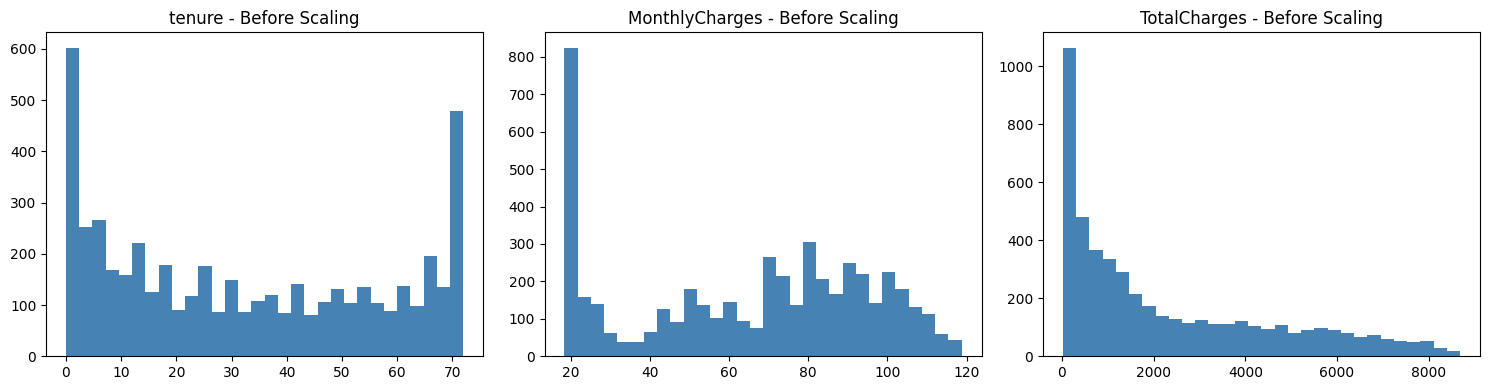

Sample after scaling:
        tenure  MonthlyCharges  TotalCharges
5557 -1.114728        0.504286     -0.837938
2270 -1.195884        0.724189     -0.909176
6930 -1.195884        0.337292     -0.911008
2257  1.117066        0.515860      1.108912
898  -0.830682        1.122660     -0.516560

Sample after normalization:
        tenure  MonthlyCharges  TotalCharges
5557  0.069444        0.615845      0.042165
2270  0.041667        0.682113      0.023321
6930  0.041667        0.565521      0.022837
2257  0.833333        0.619332      0.557146
898   0.166667        0.802192      0.127176


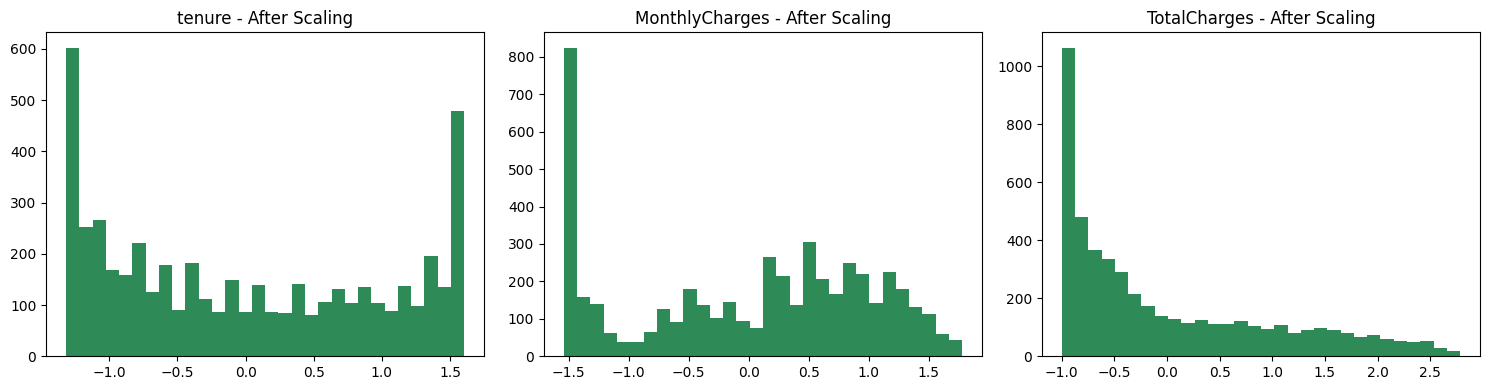

In [5]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# BEFORE: distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_data[col], bins=30, color='steelblue')
    axes[i].set_title(f'{col} - Before Scaling')
plt.tight_layout()
plt.show()

# SCALING (Standardization)
scaler = StandardScaler()
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])
print("Sample after scaling:")
print(train_data[numeric_cols].head())

# NORMALIZATION (Min-Max)
minmax = MinMaxScaler()
train_data_normalized = train_data.copy()
train_data_normalized[numeric_cols] = minmax.fit_transform(train_data[numeric_cols])
print("\nSample after normalization:")
print(train_data_normalized[numeric_cols].head())

# AFTER: distribution plots post-scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(train_data[col], bins=30, color='seagreen')
    axes[i].set_title(f'{col} - After Scaling')
plt.tight_layout()
plt.show()
